In [82]:
# imports
import numpy as np
import scipy as sp
from numpy.typing import NDArray

# Image Processing Computer Vision
import skimage as ski
import matplotlib.pyplot as plt

# ML
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from kneed import KneeLocator
from typing import Optional, Self, Tuple

In [17]:
# Functions
def ConvertRgbToLab(mRgb: NDArray) -> NDArray:
    # we get mRgb in the format of NumPixels x 3
    mRgb3D = np.reshape(mRgb, (1, -1, 3)) # we provide the input in the form of one row, needed number of collomns, 3
    mLab3D = ski.color.rgb2lab(mRgb3D)
    return np.reshape(mLab3D, (-1, 3))


In [2]:
image = ski.data.coins()

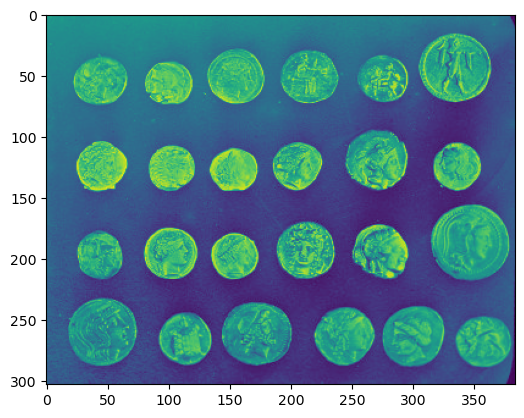

In [6]:
plt.imshow(image)

In [8]:
# data
imgUrl = r'https://github.com/FixelAlgorithmsTeam/FixelCourses/raw/master/MachineLearningMethods/2022_02/16_ParametricClustering/Fruits.jpeg'

# Model parameters
numClusters = 50
numIter = 500

In [9]:
# Load data
mI = ski.io.imread(imgUrl)
print(f'The image shape: {mI.shape}')

The image shape: (375, 500, 3)


In [11]:
mI[0, 0]

array([145,  88,   9], dtype=uint8)

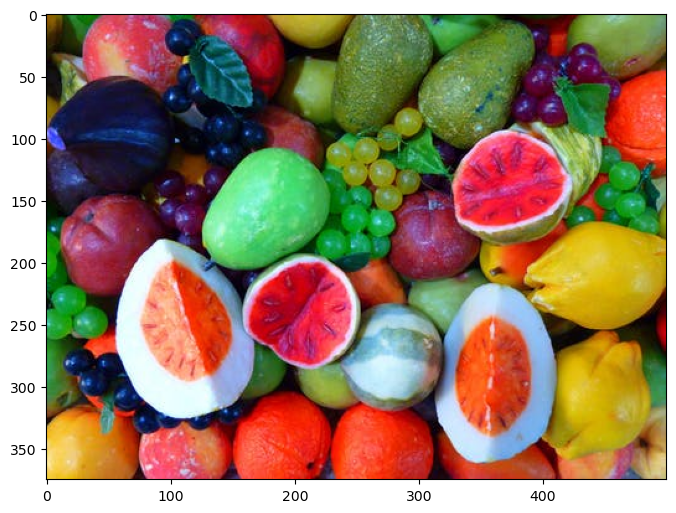

In [10]:
# plot data
fig, ax = plt.subplots(figsize = (8,8))
ax.imshow(mI)
plt.show()


In [15]:
numRows, numCols, numChannel = mI.shape

# We want to have ecery pixel as sample, as a row
mX = np.reshape(mI, (numRows * numCols, numChannel))
print(f'The features matrix shape: {mX.shape}')

The features matrix shape: (187500, 3)


In [28]:
mX = ConvertRgbToLab(mX)

In [30]:
vR = np.repeat(np.arange(numRows), numCols) # vector of the row index for each pixel
vC = np.tile(np.arange(numCols), numRows) # vector of the column index for each pixel
mX = np.column_stack((mX, vR, vC))   # for each row in feature matrix we have r, g, b, numRow, numCol

In [31]:
numFeat = mX.shape[1]
print(f'The features matrix shape: {mX.shape}')

The features matrix shape: (187500, 5)


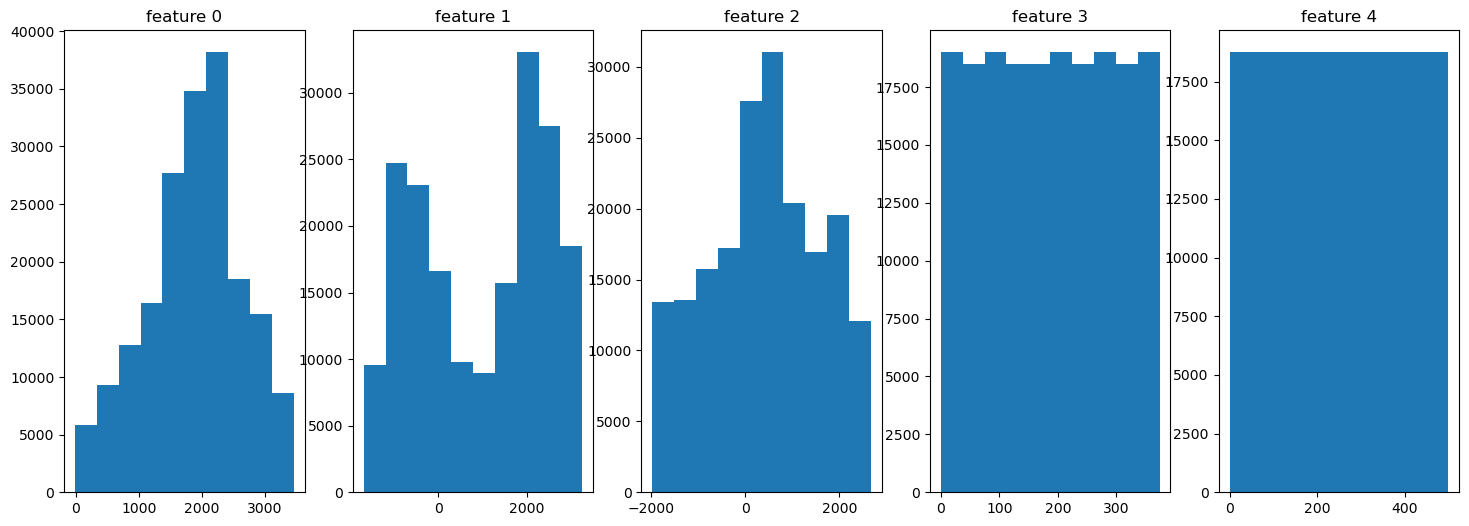

In [36]:
# now let's plot the distribution of every feature:

fig, ax = plt.subplots(nrows=1, ncols=numFeat, figsize = (18, 6))

for i in range(numFeat):
    ax[i].hist(mX[:, i])
    ax[i].set_title(f"feature {i}")

plt.show()

In [39]:
# now we want to scale each featue into [0, 1] range
oMinMaxScaler = MinMaxScaler()
mX = oMinMaxScaler.fit_transform(mX) #  scaling

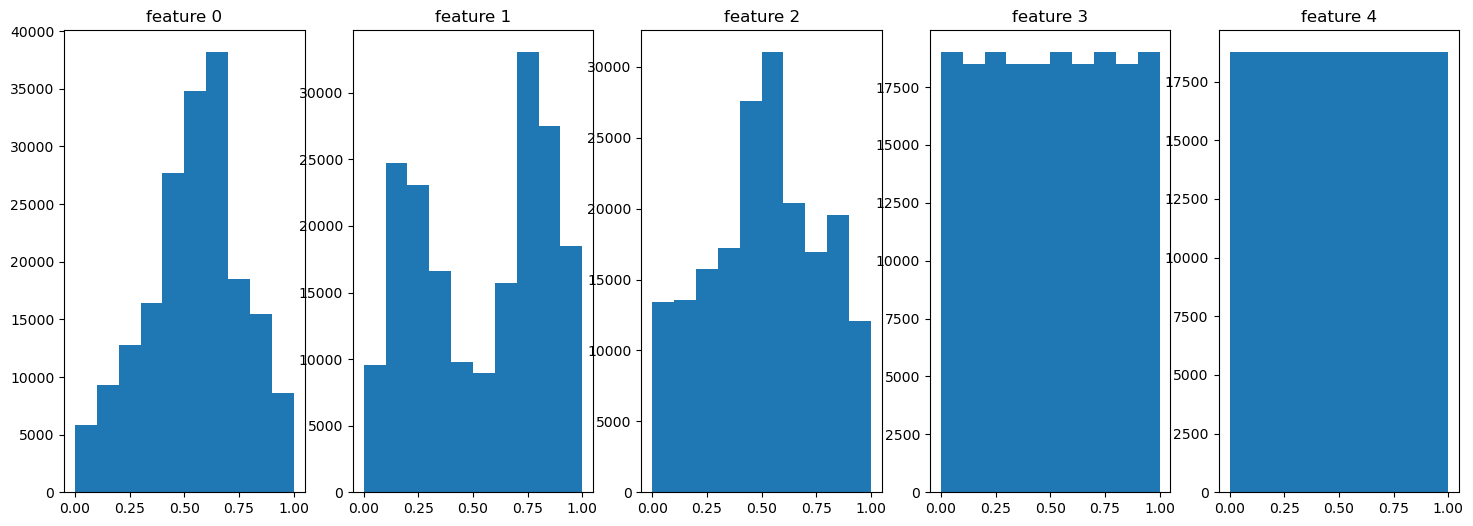

In [40]:
# let's see the distribution to visualize whther scaling wher perfomed properly

fig, ax = plt.subplots(nrows=1, ncols=numFeat, figsize = (18, 6))

for i in range(numFeat):
    ax[i].hist(mX[:, i])
    ax[i].set_title(f"feature {i}")

In [42]:
# first let's create sklearn kmeans object and train it

oKMeans_sk = KMeans(n_clusters=numClusters, max_iter=numIter)
oKMeans_sk = oKMeans_sk.fit(mX)

c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [45]:
mSuperPixel = np.reshape(oKMeans_sk.labels_, (numRows, numCols))

In [48]:
mO = ski.segmentation.mark_boundaries(image=mI, label_img=mSuperPixel, color=(0.0, 1.0, 1.0))

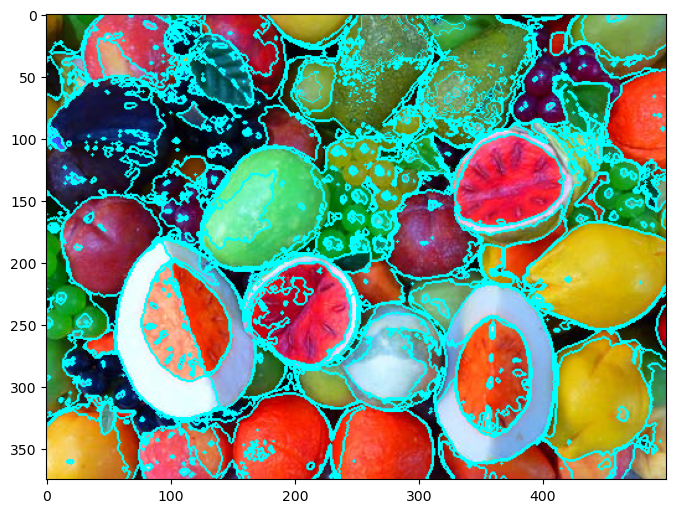

In [50]:
fig, ax = plt.subplots(figsize = (8,8))
ax.imshow(mO)
plt.show()

In [60]:
lK = [10, 25, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 100, 150, 200, 250, 300]
numK =len(lK)
vS = np.full(shape = numK, fill_value=np.nan)

for ii, kVal in enumerate(lK):
    oKmeans = KMeans(n_clusters=kVal, max_iter=numIter)
    oKmeans = oKmeans.fit(mX)
    vS[ii] = oKmeans.inertia_
    print(f"Finishing processing the {ii + 1}  from {numK} ineration with K = {kVal}")


Finishing processing the 1  from 18 ineration with K = 10
Finishing processing the 2  from 18 ineration with K = 25
Finishing processing the 3  from 18 ineration with K = 35
Finishing processing the 4  from 18 ineration with K = 40
Finishing processing the 5  from 18 ineration with K = 45
Finishing processing the 6  from 18 ineration with K = 50
Finishing processing the 7  from 18 ineration with K = 55
Finishing processing the 8  from 18 ineration with K = 60
Finishing processing the 9  from 18 ineration with K = 65
Finishing processing the 10  from 18 ineration with K = 70
Finishing processing the 11  from 18 ineration with K = 75
Finishing processing the 12  from 18 ineration with K = 80
Finishing processing the 13  from 18 ineration with K = 85
Finishing processing the 14  from 18 ineration with K = 100
Finishing processing the 15  from 18 ineration with K = 150
Finishing processing the 16  from 18 ineration with K = 200
Finishing processing the 17  from 18 ineration with K = 250
Fi

In [61]:
vS

array([17566.51543128,  9460.08429866,  7165.08792912,  6313.66838198,
        5776.72336165,  5467.94858117,  5020.7157219 ,  4783.01688796,
        4547.68056787,  4271.72154607,  4129.07309551,  3898.30201696,
        3750.77600663,  3323.16913647,  2444.70229333,  2008.14451777,
        1713.33372415,  1514.48160009])

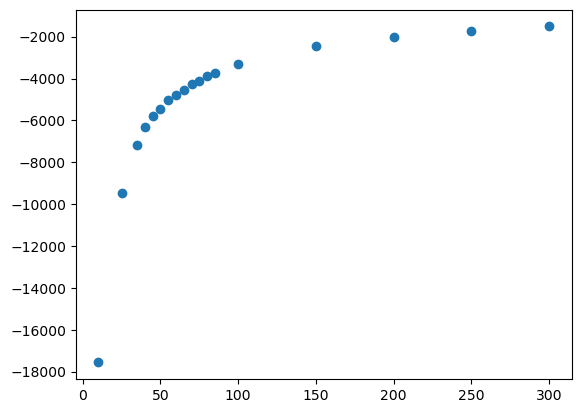

In [62]:
plt.scatter(lK, -vS)

In [73]:
oKneeLoc = KneeLocator(lK, vS, curve='concave', direction='increasing')
kneeK = round(oKneeLoc.knee)

In [78]:
oKneeLoc.knee

np.int64(10)

In [71]:
lK[kneeK]

75

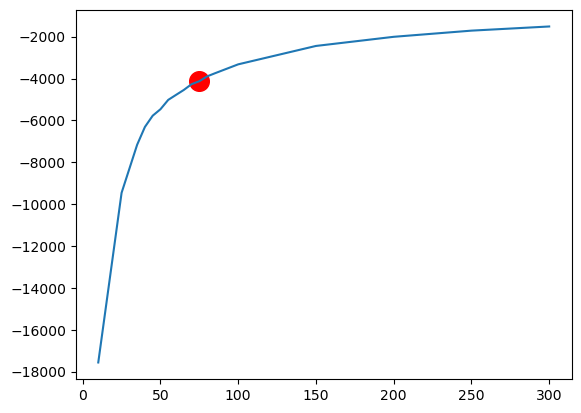

In [77]:
plt.plot(lK, -vS)
plt.scatter(lK[kneeK], -vS[kneeK], s=200, color='red' )

In [ ]:
class KMeansCluster(ClusterMixin, BaseEstimator):
    def __init__(self, numClasters:int, numIter:int, metricType:str='euclidean'):
        self.numClusters = numClasters
        self.numIter = numIter
        self.metricType = metricType

        pass

    def fit(self, mX, vY=None):
        numSamples = mX.shape[0]
        featuresDim = mX.shape[1]

        if(numSamples < self.numClusters);
            raise ValueError(f"Number of samples: {numSamples} must be not smaller then number of clasters: {self.numClusters}!")
        
        mC = mX[np.random.choice(numSamples, self.numClusters, replace=False)] # random selection of initial centroids from feature matrix as a way to start
        vL = np.zeros(numSamples, dtype=np.int64) #initialization of cluster labels with zero
        vF = np.zeros(numSamples, dtype=np.bool) #claster flags, i suppose whether claster defined or not

        for ii in range(self.numIter):
            mD = sp.spatial.distance.cdist(mX, mC, self.metricType) #natrix of distances
            vL = np.argmin(mD, axis=1, out=vL) #for every sample provide index of column with minimal distance

            for kk in range(numClusters):

                # for every every claster kk created mask vF
                vF = np.equal(vL, kk, out = vF)
                if np.any(vF):
                    mC[kk, :] = np.mean(mX[vL == kk, :], axis = 0)

        self.claster_centers_ = mC
        self.labels_ = vL
        self.inertia_ = np.sum(np.amin(mD, axis=1))
        self.n_iter_ = self.numIter
        self.n_features_in = featuresDim

        return self





    